#### Install and import packages

In [93]:
%pip install earthengine-api geemap cartopy
import ee
import geemap

Note: you may need to restart the kernel to use updated packages.


#### Authenticate and initalise Earth engine project

In [94]:
ee.Authenticate()
ee.Initialize(project='editorial-democraticprimaries')

#### Russia China border geometry

In [95]:
# convert geojson to ee object
russiaChinaBorderObject  = geemap.geojson_to_ee('china-russia-border.geojson')
russiaChinaBorderGeom = russiaChinaBorderObject.geometry()
russiaChinaBorderGeomBuffered = russiaChinaBorderGeom.buffer(100000) # buffer by 50km

#### Initialise nightlights dataset

In [96]:
nightlights = ee.ImageCollection('NASA/VIIRS/002/VNP46A2')
latest = nightlights.sort('system:time_start', False).first()
print('Latest image date: ' + latest.date().format().getInfo())

nightlights_filtered = nightlights.filter(ee.Filter.date('2017-01-01', latest.date())).select('Gap_Filled_DNB_BRDF_Corrected_NTL')
nighttimeVis = {min: 0.0, max: 1.0};


Latest image date: 2026-09-08T00:00:00


### Percentage nightlights change

In [97]:
# --- Scaled nightlights (no masking) ------------------------------------
# VNP46A2 NTL bands are stored with a 0.1 scale factor -> nW/cm2/sr
SCALE = 0.1

# Season filter (not a mask - it just selects which nights go into the median).
# Set SEASON = None to use the whole year; winter snow will then inflate
# radiance at this latitude.
SEASON = ee.Filter.calendarRange(5, 9, 'month')   # May-September

def to_ntl(img):
    return (img.select('Gap_Filled_DNB_BRDF_Corrected_NTL')
               .multiply(SCALE)
               .rename('NTL')
               .copyProperties(img, ['system:time_start']))

ntl = nightlights.filter(SEASON) if SEASON else nightlights
ntl = ntl.map(to_ntl)

def composite(start, end):
    return ntl.filter(ee.Filter.date(start, end)).median().rename('NTL')

In [98]:
# --- Baseline vs recent -------------------------------------------------
baseNTL   = composite('2017-01-01', '2018-01-01')
recentNTL = composite('2025-01-01', '2026-01-01')

abs_change = recentNTL.subtract(baseNTL).rename('abs_change')

# Denominator floor (nW/cm2/sr). Not a mask - nothing is hidden - it just stops
# near-zero background pixels from turning sensor noise into +/-1000%.
# Set DENOM_FLOOR = 0 for the raw ratio.
DENOM_FLOOR = 0.5

pct_change = (recentNTL.subtract(baseNTL)
                .divide(baseNTL.max(DENOM_FLOOR))
                .multiply(100)
                .rename('pct_change'))

buf = russiaChinaBorderGeomBuffered

In [99]:
# --- Map ----------------------------------------------------------------
# Log stretch on the reference layer: settlement radiance spans 3+ orders of
# magnitude, so a linear stretch shows either cities or villages, never both.
log_recent = recentNTL.max(0.05).log10()

ntlVis    = {'min': -1.3, 'max': 1.7, 'palette': ["#2c0b54",'#3b0f70','#8c2981','#de4968','#fe9f6d','#fcfdbf']}
changeVis = {'min': -100, 'max': 100, 'palette': ['#b2182b', '#f7f7f7', '#2166ac']}
absVis    = {'min': -5,   'max': 5,   'palette': ['#b2182b', '#f7f7f7', '#2166ac']}

NightlightsMap = geemap.Map(center=[48, 128], zoom=5)

# English-language basemap. The default OSM basemap labels places in the local
# script (Cyrillic / Chinese); Google's tiles honour an hl= language parameter.
NightlightsMap.clear_layers()
NightlightsMap.add_tile_layer(
    url='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}&hl=en',
    name='Google Roads (EN)',
    attribution='Google',
)

NightlightsMap.addLayer(log_recent.clip(buf),  ntlVis,    'NTL 2025 (log10)')
NightlightsMap.addLayer(abs_change.clip(buf),  absVis,    'Absolute NTL change', False)
NightlightsMap.addLayer(pct_change.clip(buf),  changeVis, '% NTL change 2017 -> 2025')
NightlightsMap.addLayer(buf, {}, 'Border buffer (50km)', False)
NightlightsMap.addLayer(russiaChinaBorderGeom, {}, 'Border', True)
NightlightsMap

Map(center=[48, 128], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

### Populated places 


In [100]:


# convert geojson to ee object
populatedPlacesObject = geemap.geojson_to_ee('populated-places-clipped.geojson')
populatedPlacesObjectClipped = populatedPlacesObject.filterBounds(russiaChinaBorderGeomBuffered)
populatedPlacesGeom =populatedPlacesObjectClipped.geometry()
populatedPlacesGeomBuffered = populatedPlacesGeom.buffer(10000)

##GEODATAFRAME of populated places
import geopandas as gpd
populatedPlacesGDF = gpd.read_file('populated-places-clipped.geojson')
populatedPlacesGDF = populatedPlacesGDF.to_crs(epsg=4326) 





In [101]:
PlacesMap = geemap.Map(center=[48, 128], zoom=5)
PlacesMap.addLayer(russiaChinaBorderGeomBuffered, {}, 'Russia-China Border Buffer (50km)')
PlacesMap.addLayer(populatedPlacesGeomBuffered, {}, 'Populated Places Buffer (10km)')
PlacesMap


Map(center=[48, 128], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

In [102]:
### Clip nightlights to populated places buffer
NightlightsClipped = abs_change.clip(populatedPlacesGeomBuffered)
url = NightlightsClipped.getThumbURL({
      'min': -5, 'max': 5,
      'palette': ['#b2182b', '#f7f7f7', '#2166ac'],  # reuse absVis
      'region': populatedPlacesGeomBuffered,  # or an explicit bbox
      'dimensions': 1024,   # max side in px
      'format': 'png'
  })


NightlightsMap.addLayer(NightlightsClipped,  absVis,    'abs change buffer')
NightlightsMap

Map(center=[48, 128], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tra…

### Small multiples: absolute nightlight change per populated place



In [103]:
eePlaces = populatedPlacesObject.filterBounds(russiaChinaBorderGeomBuffered)

chinaPlaces  = eePlaces.filter(ee.Filter.eq('ADM0NAME', 'China')).sort('POP_MAX', False)
russiaPlaces = eePlaces.filter(ee.Filter.eq('ADM0NAME', 'Russia')).sort('POP_MAX', False)

N_PER_SIDE = 24   
BOX_KM     = 10  

print('China places: ', chinaPlaces.size().getInfo())
print('Russia places:', russiaPlaces.size().getInfo())

China places:  14
Russia places: 22


In [104]:
# --- Populated places within the border buffer, as a GeoDataFrame -------
METRIC_CRS = '+proj=aeqd +lat_0=48 +lon_0=128 +datum=WGS84 +units=m +no_defs'

BUFFER_KM = 50  
borderGDF = gpd.read_file('china-russia-border.geojson').to_crs(epsg=4326)

_buf = borderGDF.to_crs(METRIC_CRS).buffer(BUFFER_KM * 1000)
borderBuffer = _buf.union_all() if hasattr(_buf, 'union_all') else _buf.unary_union

inBuffer = populatedPlacesGDF.to_crs(METRIC_CRS).within(borderBuffer)
places = (populatedPlacesGDF[inBuffer]
          .sort_values(['ADM0NAME', 'POP_MAX'], ascending=[True, False])
          .reset_index(drop=True))

print('Places within %d km of the border: %d' % (BUFFER_KM, len(places)))
print(places['ADM0NAME'].value_counts().to_string())

Places within 50 km of the border: 18
ADM0NAME
Russia         11
China           6
North Korea     1


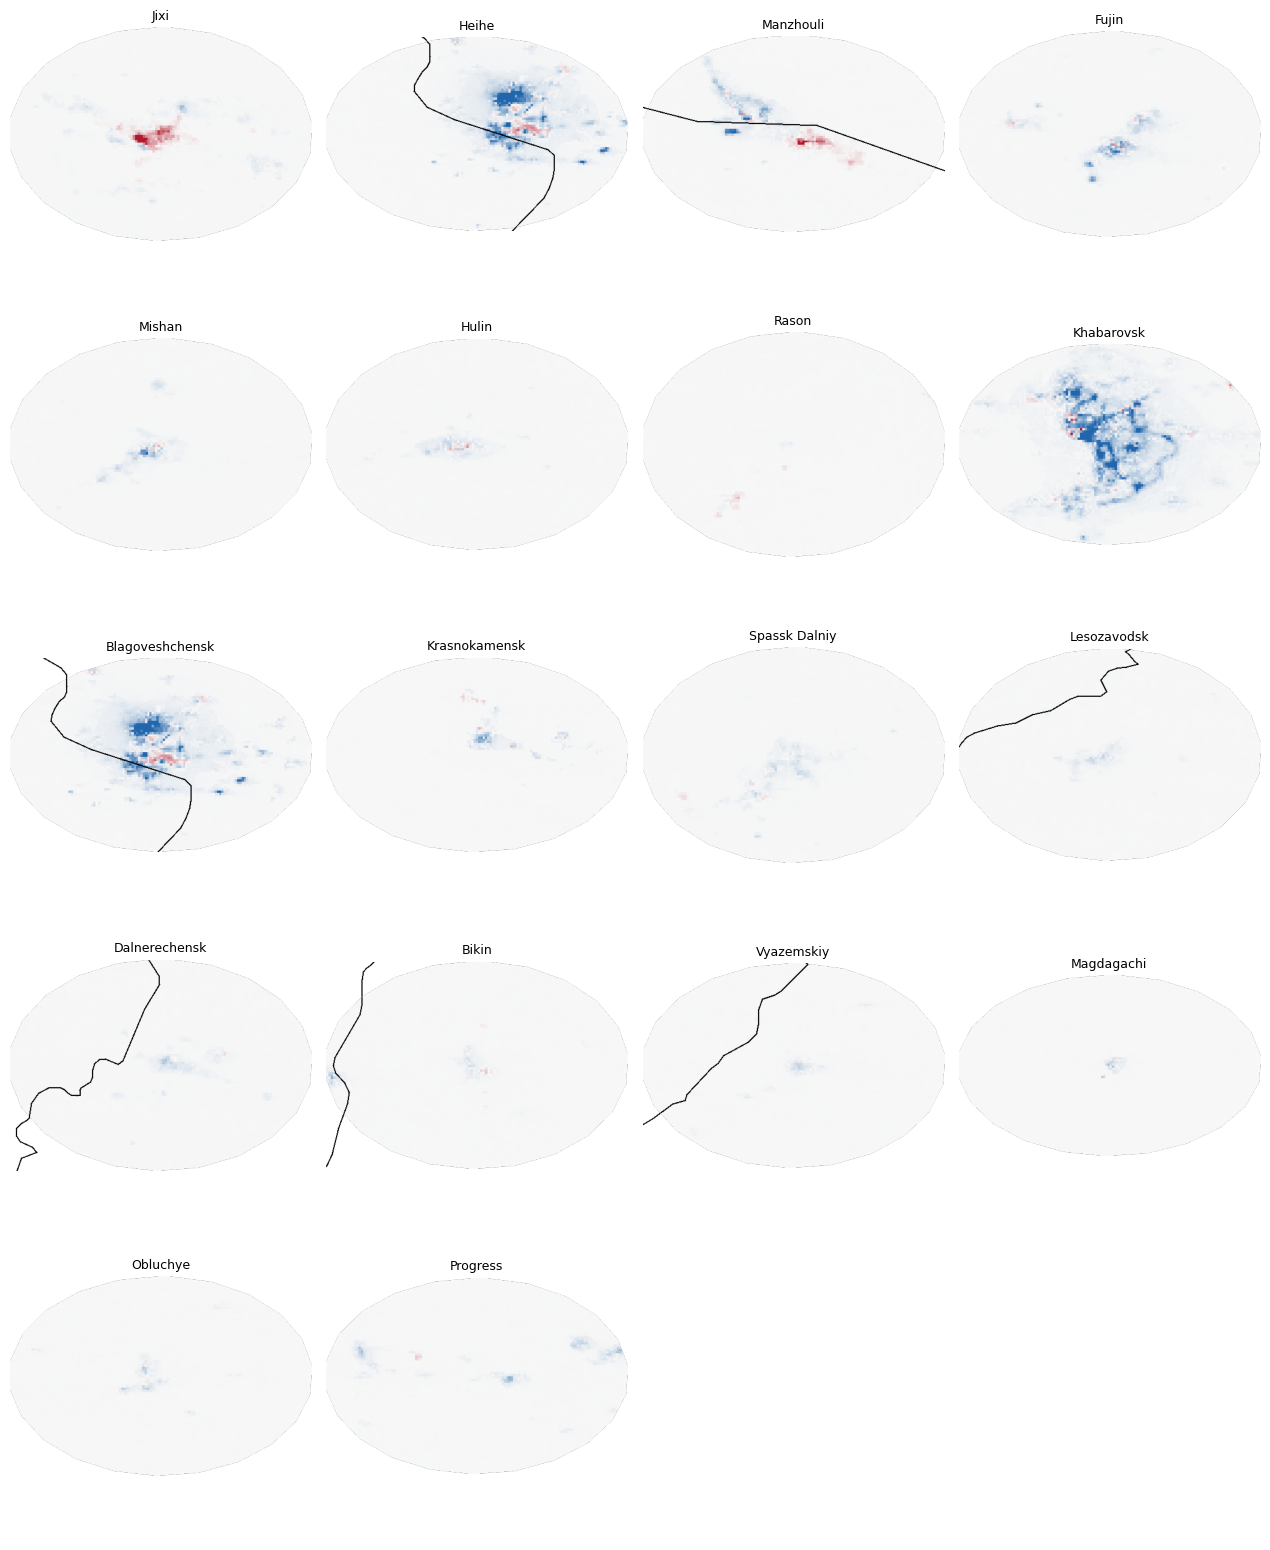

In [105]:
import math
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 
from io import BytesIO

NCOLS = 4
NROWS = math.ceil(len(places) / NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(3.2 * NCOLS, 3.2 * NROWS))
axes_flat = axes.flatten()

for ax in axes_flat:
    ax.axis('off')  # blank out any leftover panels on the last row

# Rasterize the border once, reused for every place thumbnail below.
borderOutline = ee.Image().byte().paint(
    ee.FeatureCollection([ee.Feature(russiaChinaBorderGeom)]), 1, 2
)  # 1 = paint value, 2 = line width in pixels
borderVis = borderOutline.visualize(palette=['000000']).updateMask(borderOutline)

for i, row in places.iterrows():
    place_geom = ee.Geometry.Point([row.geometry.x,
    row.geometry.y]).buffer(20000)
    clipped = abs_change.clip(place_geom)

    clippedVis = clipped.visualize(min=-5, max=5, palette=['#b2182b', '#f7f7f7', '#2166ac'])
    combined = clippedVis.blend(borderVis)

    url = combined.getThumbURL({
          'region': place_geom,
          'dimensions': 512,
          'format': 'png'
    })

    with urllib.request.urlopen(url) as resp:
        img = mpimg.imread(BytesIO(resp.read()), format='png')

    ax = axes_flat[i]
    ax.imshow(img)
    ax.set_title(row['NAME'], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Alpha Earth embeddings

In [106]:
alphaEarthData = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
point = ee.Geometry.Point(127.533280,50.257409);

image1 = alphaEarthData.filterDate('2017-01-01', '2018-01-01').filterBounds(point).mosaic()
image2 = alphaEarthData.filterDate('2024-01-01', '2025-01-01').filterBounds(point).mosaic()


alphaEarthVis = {'min': -0.3, 'max': 0.3, 'bands': ['A01', 'A16', 'A09']}

alphaEarthMap = geemap.Map(center=[50.257409, 127.533280], zoom=8)

# alphaEarthMap.centerObject(populatedPlacesGeomBuffered)

# alphaEarthMap.addLayer(alphaEarthData.clip(populatedPlacesGeomBuffered) , alphaEarthVis, 'Alpha Earth');
alphaEarthMap.addLayer(image1, alphaEarthVis, '2017')
alphaEarthMap.addLayer(image2, alphaEarthVis, '2024')

alphaEarthMap

Map(center=[50.257409, 127.53328], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

### Change detection

In [107]:
dotProd = image1.multiply(image2).reduce(ee.Reducer.sum());

alphaEarthMap.addLayer(
  dotProd,
  {min: 0, max: 1, 'palette': ['yellow', 'black']},
  'Similarity between years (brighter = less similar)'
);